
# Triadic Cell Notebook v5
## Addressed memory, selective recall, triadic write gate

v4 gave us the first substrate-like result:

- vector latent state
- selective readout
- external persistent memory
- baseline comparison

v5 adds the missing piece for something that starts to smell like cognition:

1. **memory slots**
2. **addressing**
3. **selective recall**
4. **triadic write gate**

This means the machine no longer just stores "more memory".
It has to decide **where** readable difference belongs.

That is closer to:
- query
- match
- recall
- update
- rewrite

which is the first bridge toward a real AI substrate.



## Hardware translation

Use the machine picture again:

- **Binding (B)** = protect register + keep identity alive
- **Transformation (T)** = update rule / lawful change
- **Readout (R)** = bus projection of meaningful delta
- **Addressed memory** = persistent slots
- **Selective recall** = choose a slot based on current need/query
- **Triadic write gate** = only write memory when held + changed + legible

That last rule matters.

A normal TR-style machine can emit.
A triadic machine can emit **and decide what deserves to persist**.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)



## Addressed memory bank

This is a real step up from a single memory register.

The bank has:
- multiple slots
- a read path
- a write path
- leak
- competition across slots

The machine has to choose what it is talking to.


In [3]:

class AddressedMemoryBank:
    def __init__(self, slots: int = 4, width: int = 4, leak: float = 0.015):
        self.slots = np.zeros((slots, width), dtype=float)
        self.leak = float(leak)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray) -> np.ndarray:
        # similarity by dot product
        scores = self.slots @ query
        return self._softmax(scores, temp=0.25)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float):
        # decay
        self.slots *= (1.0 - self.leak)

        # normalized outer update
        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(
                self.slots[i] + strength * weights[i] * value,
                0.0, 1.0
            )

    def mean_level(self) -> float:
        return float(self.slots.mean())

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)



## TriadicCellV5

New ingredients:

1. latent state generates a **query**
2. query addresses memory slots
3. recalled memory folds back into transformation
4. readout is still projected bound transformed difference
5. memory write only happens through a **triadic gate**

That means:
- the machine can now remember *selectively*
- and old memory can shape new state


In [4]:

class TriadicCellV5:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [0.9, 0.0, 0.3, 0.0],
            [0.0, 0.8, 0.0, 0.4],
            [0.3, 0.0, 0.7, 0.0],
            [0.0, 0.4, 0.0, 0.9],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        memory_bank: AddressedMemoryBank,
    ) -> Tuple[AddressedTriadicState, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:

        # --- address / recall ---
        raw_query = self.W_query @ s.latent
        query = raw_query / (np.linalg.norm(raw_query) + 1e-8)
        addr = memory_bank.address(query)
        recalled = memory_bank.read(addr)

        # --- binding / coherence ---
        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        # --- transformation / latent update ---
        target = np.array([
            0.15 + 0.70 * drive_vec[0],
            0.20 + 0.60 * drive_vec[1],
            0.25 + 0.55 * drive_vec[2],
            0.10 + 0.75 * drive_vec[3],
        ], dtype=float)

        # recalled memory acts like context pressure folded into update
        composite_target = 0.72 * target + 0.28 * recalled

        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent

        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)
        delta_vec = np.abs(latent - s.latent)

        # --- readout / bus ---
        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        # --- triadic write gate ---
        # only write when held + changed + legible
        write_strength = float(0.55 * support * readout.mean())
        memory_bank.write(addr, latent, write_strength)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, readout.copy(), delta_vec.copy(), recalled.copy(), addr.copy(), write_strength



## Plain TR addressed baseline

This machine can still address memory, but it lacks true binding-centered persistence.
So memory access becomes noisy and weak rather than structurally grounded.


In [5]:

class PlainTRAddressedBaseline:
    def __init__(self):
        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        memory_bank: AddressedMemoryBank,
    ) -> Tuple[AddressedTriadicState, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:

        query = s.latent / (np.linalg.norm(s.latent) + 1e-8)
        addr = memory_bank.address(query)
        recalled = memory_bank.read(addr)

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))

        target = np.array([
            0.15 + 0.70 * drive_vec[0],
            0.20 + 0.60 * drive_vec[1],
            0.25 + 0.55 * drive_vec[2],
            0.10 + 0.75 * drive_vec[3],
        ], dtype=float)

        composite_target = 0.72 * target + 0.28 * recalled
        latent = self._clip(s.latent + 0.10 * coherence * (composite_target - s.latent) - 0.18 * s.latent)
        delta_vec = np.abs(latent - s.latent)

        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.35 * projected - 0.35 * s.readout)

        # weak non-triadic write
        write_strength = float(0.08 * readout.mean())
        memory_bank.write(addr, latent, write_strength)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state, readout.copy(), delta_vec.copy(), recalled.copy(), addr.copy(), write_strength



## Vector drive


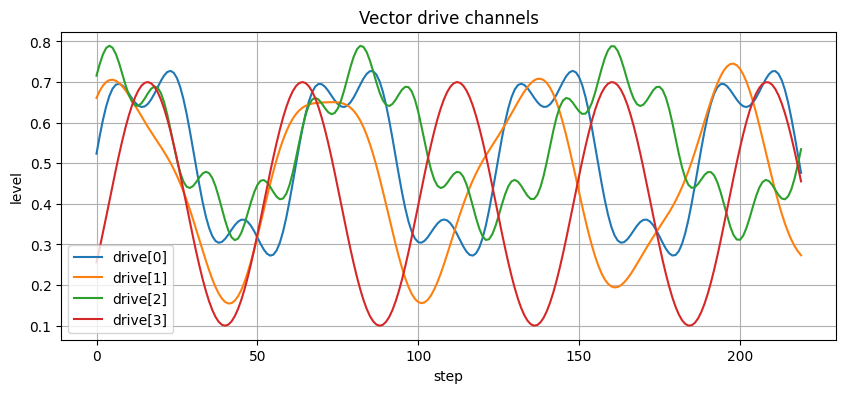

In [6]:

def make_drive(steps: int = 220) -> np.ndarray:
    t = np.linspace(0, 7 * np.pi, steps)

    v0 = np.clip(0.50 + 0.22 * np.sin(t) + 0.08 * np.sin(3.0 * t + 0.3), 0.0, 1.0)
    v1 = np.clip(0.45 + 0.25 * np.sin(t + 0.7) + 0.05 * np.cos(2.2 * t), 0.0, 1.0)
    v2 = np.clip(0.55 + 0.18 * np.cos(0.8 * t - 0.4) + 0.06 * np.sin(4.0 * t), 0.0, 1.0)
    v3 = np.clip(0.40 + 0.30 * np.sin(1.3 * t - 0.5), 0.0, 1.0)

    return np.vstack([v0, v1, v2, v3]).T

drive = make_drive()

plt.figure(figsize=(10, 4))
for i in range(drive.shape[1]):
    plt.plot(drive[:, i], label=f"drive[{i}]")
plt.title("Vector drive channels")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()



## Run structural cases + baseline


In [7]:

def run_case(name: str, B: float, T: float, R: float, steps: int = 220) -> Tuple[pd.DataFrame, np.ndarray]:
    cell = TriadicCellV5(B, T, R)
    state = AddressedTriadicState()
    bank = AddressedMemoryBank(slots=4, width=4, leak=0.015 + 0.08 * (1.0 - B))

    rows: List[Dict[str, float]] = []

    for i, d in enumerate(make_drive(steps)):
        state, readout, delta_vec, recalled, addr, write_strength = cell.step(state, d, bank)
        rows.append({
            "step": i,
            "case": name,
            "coherence": state.coherence,
            "mean_latent": float(state.latent.mean()),
            "mean_delta": float(delta_vec.mean()),
            "mean_readout": float(readout.mean()),
            "mean_recall": float(recalled.mean()),
            "mean_memory_bank": bank.mean_level(),
            "write_strength": write_strength,
            "slot_focus": float(addr.max()),
        })

    return pd.DataFrame(rows), bank.slot_energy()


def run_baseline(name: str = "Plain TR addressed baseline", steps: int = 220) -> Tuple[pd.DataFrame, np.ndarray]:
    cell = PlainTRAddressedBaseline()
    state = AddressedTriadicState()
    bank = AddressedMemoryBank(slots=4, width=4, leak=0.015)

    rows: List[Dict[str, float]] = []

    for i, d in enumerate(make_drive(steps)):
        state, readout, delta_vec, recalled, addr, write_strength = cell.step(state, d, bank)
        rows.append({
            "step": i,
            "case": name,
            "coherence": state.coherence,
            "mean_latent": float(state.latent.mean()),
            "mean_delta": float(delta_vec.mean()),
            "mean_readout": float(readout.mean()),
            "mean_recall": float(recalled.mean()),
            "mean_memory_bank": bank.mean_level(),
            "write_strength": write_strength,
            "slot_focus": float(addr.max()),
        })

    return pd.DataFrame(rows), bank.slot_energy()

results = {}
slot_energies = {}

for name, vals in {
    "BTR": (1.0, 1.0, 1.0),
    "BT only": (1.0, 1.0, 0.0),
    "BR only": (1.0, 0.0, 1.0),
    "TR only": (0.0, 1.0, 1.0),
}.items():
    df, slots = run_case(name, *vals)
    results[name] = df
    slot_energies[name] = slots

df_base, slots_base = run_baseline()
results["Plain TR addressed baseline"] = df_base
slot_energies["Plain TR addressed baseline"] = slots_base

pd.concat(results.values(), ignore_index=True).head()


,step,case,coherence,mean_latent,mean_delta,mean_readout,mean_recall,mean_memory_bank,write_strength,slot_focus
0,0,BTR,0.726000,0.309993,0.012646,0.030238,0.000000,0.000936,0.012074,0.25
1,1,BTR,0.731336,0.320825,0.012260,0.055884,0.000936,0.002725,0.022478,0.25
2,2,BTR,0.736101,0.332231,0.011885,0.077176,0.002725,0.005279,0.031245,0.25
3,3,BTR,0.740377,0.343883,0.011652,0.094016,0.005279,0.008491,0.038284,0.25
4,4,BTR,0.744240,0.355426,0.011543,0.106288,0.008491,0.012229,0.043507,0.25


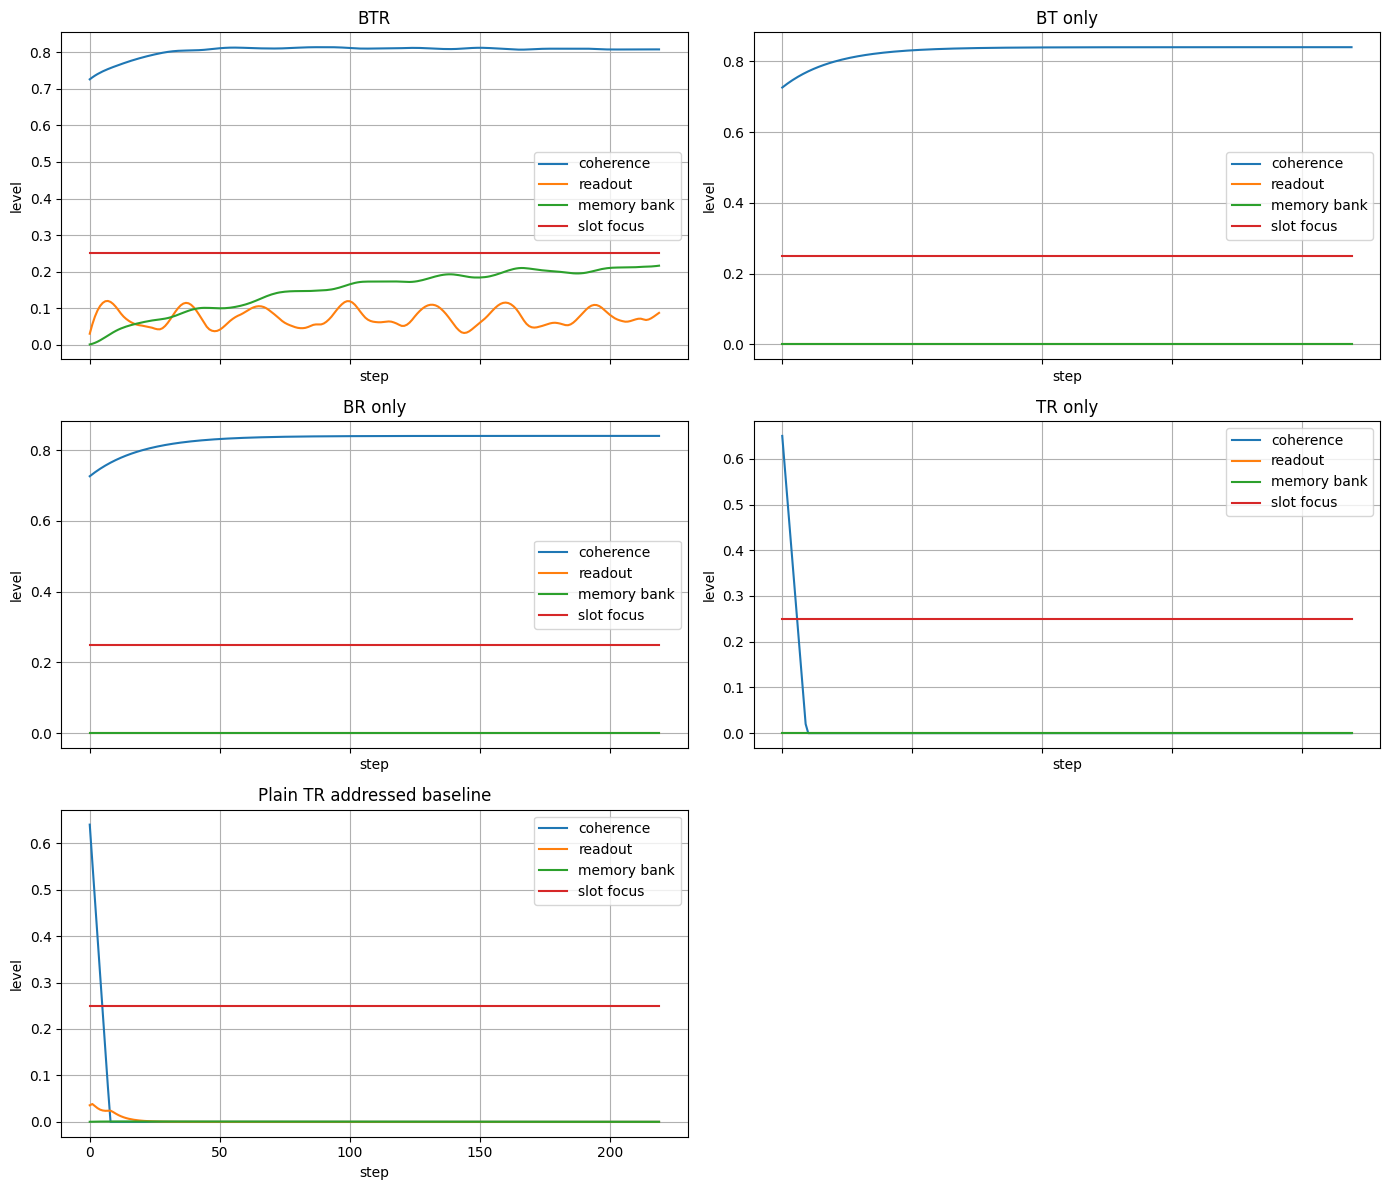

In [8]:

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.ravel()

for ax, (name, df) in zip(axes, results.items()):
    ax.plot(df["step"], df["coherence"], label="coherence")
    ax.plot(df["step"], df["mean_readout"], label="readout")
    ax.plot(df["step"], df["mean_memory_bank"], label="memory bank")
    ax.plot(df["step"], df["slot_focus"], label="slot focus")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")

if len(results) < len(axes):
    for ax in axes[len(results):]:
        ax.axis("off")

plt.tight_layout()
plt.show()



## Summary table


In [9]:

summary = pd.DataFrame([
    {
        "case": name,
        "final_coherence": df["coherence"].iloc[-1],
        "final_readout": df["mean_readout"].iloc[-1],
        "final_memory_bank": df["mean_memory_bank"].iloc[-1],
        "final_slot_focus": df["slot_focus"].iloc[-1],
        "mean_coherence": df["coherence"].mean(),
        "mean_delta": df["mean_delta"].mean(),
        "mean_readout": df["mean_readout"].mean(),
        "mean_recall": df["mean_recall"].mean(),
        "mean_memory_bank": df["mean_memory_bank"].mean(),
        "mean_write_strength": df["write_strength"].mean(),
        "mean_slot_focus": df["slot_focus"].mean(),
    }
    for name, df in results.items()
]).sort_values(["mean_memory_bank", "mean_readout"], ascending=False)

summary


,case,final_coherence,final_readout,final_memory_bank,final_slot_focus,mean_coherence,mean_delta,mean_readout,mean_recall,mean_memory_bank,mean_write_strength,mean_slot_focus
0,BTR,0.807816,8.726943e-02,0.216306,0.25,0.804461,0.006844,0.074655,0.149275,0.150259,0.033011,0.25
4,Plain TR addressed baseline,0.000000,1.746109e-20,0.000034,0.25,0.012972,0.001364,0.001731,0.000261,0.000261,0.000139,0.25
1,BT only,0.839998,0.000000e+00,0.000000,0.25,0.829636,0.006935,0.000000,0.000000,0.000000,0.000000,0.25
2,BR only,0.839998,0.000000e+00,0.000000,0.25,0.829636,0.000000,0.000000,0.000000,0.000000,0.000000,0.25
3,TR only,0.000000,0.000000e+00,0.000000,0.25,0.015227,0.001364,0.000000,0.000000,0.000000,0.000000,0.25



## Slot energy by case

This shows where the machine ended up writing.
A real addressed machine should not just store more.
It should produce a selective persistence pattern.


In [10]:

slot_df = pd.DataFrame(slot_energies).T
slot_df.columns = [f"slot_{i}" for i in range(slot_df.shape[1])]
slot_df


,slot_0,slot_1,slot_2,slot_3
BTR,0.216306,0.216306,0.216306,0.216306
BT only,0.000000,0.000000,0.000000,0.000000
BR only,0.000000,0.000000,0.000000,0.000000
TR only,0.000000,0.000000,0.000000,0.000000
Plain TR addressed baseline,0.000034,0.000034,0.000034,0.000034



## Scorecard


In [11]:

def classify(df: pd.DataFrame) -> Dict[str, str]:
    mean_c = df["coherence"].mean()
    mean_d = df["mean_delta"].mean()
    mean_r = df["mean_readout"].mean()
    mean_m = df["mean_memory_bank"].mean()
    mean_f = df["mean_slot_focus"].mean()

    return {
        "coherence": "high" if mean_c > 0.58 else "low",
        "statefulness": "high" if mean_d > 0.008 else "low",
        "readability": "high" if mean_r > 0.05 else "low",
        "memory": "high" if mean_m > 0.08 else "low",
        "address_focus": "high" if mean_f > 0.35 else "low",
    }

scorecard = pd.DataFrame({name: classify(df) for name, df in results.items()}).T
scorecard


KeyError: 'mean_slot_focus'


## One chained BTR addressed machine


In [ ]:

def run_chain(depth: int = 4, steps: int = 220, B: float = 1.0, T: float = 1.0, R: float = 1.0) -> pd.DataFrame:
    cells = [TriadicCellV5(B, T, R) for _ in range(depth)]
    states = [AddressedTriadicState() for _ in range(depth)]
    banks = [AddressedMemoryBank(slots=4, width=4, leak=0.015) for _ in range(depth)]

    rows = []

    for i, d in enumerate(make_drive(steps)):
        signal = d.copy()
        deltas = []
        foci = []

        for j, cell in enumerate(cells):
            states[j], readout, delta_vec, recalled, addr, write_strength = cell.step(states[j], signal, banks[j])

            signal = np.array([
                readout[0],
                readout[1],
                recalled.mean(),
                banks[j].mean_level(),
            ], dtype=float)

            deltas.append(delta_vec.mean())
            foci.append(addr.max())

        rows.append({
            "step": i,
            "mean_coherence": np.mean([s.coherence for s in states]),
            "mean_readout": np.mean([s.readout.mean() for s in states]),
            "mean_memory_bank": np.mean([b.mean_level() for b in banks]),
            "mean_delta": np.mean(deltas),
            "mean_focus": np.mean(foci),
        })

    return pd.DataFrame(rows)

chain_df = run_chain(depth=4, steps=220, B=1.0, T=1.0, R=1.0)

plt.figure(figsize=(10, 5))
plt.plot(chain_df["step"], chain_df["mean_coherence"], label="mean coherence")
plt.plot(chain_df["step"], chain_df["mean_readout"], label="mean readout")
plt.plot(chain_df["step"], chain_df["mean_memory_bank"], label="mean memory bank")
plt.plot(chain_df["step"], chain_df["mean_focus"], label="mean address focus")
plt.title("4-cell addressed BTR chain")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

chain_df.tail()



## Read the result

The intended pattern is now:

- **BTR** should be the only case that is strong on:
  - coherence
  - readable activity
  - memory persistence
  - addressed writing
- **BT only** should stay alive internally but not write meaningful readable memory
- **BR only** should remain a coherent shell
- **TR only** should collapse
- **Plain TR addressed baseline** should look weaker and noisier than real BTR

If that holds, the machine has moved one step closer to a substrate that can:
- hold state
- transform state
- expose state
- decide what difference deserves to persist
